In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mt

In [3]:
df = pd.read_csv('../data/demand_2026.csv')

In [5]:
df

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,FORECAST_ACTUAL_INDICATOR,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
0,2026-01-01,1,25107,A,29668,23625,4146,6417,0,22267,...,-1143,-610,989,-361,-527,209,677,-352,1021,-513
1,2026-01-01,2,25881,A,30361,24341,4188,6417,0,22267,...,-1132,-606,1005,-361,-453,243,648,-359,994,-514
2,2026-01-01,3,25355,A,30681,23805,4085,6417,0,22267,...,-1433,-594,844,-361,-524,343,667,-754,994,-514
3,2026-01-01,4,24762,A,30225,23226,4092,6417,0,22267,...,-1469,-589,837,-361,-531,346,650,-770,990,-514
4,2026-01-01,5,24111,A,29092,22653,4044,6417,0,22267,...,-1236,-431,949,-361,-531,146,413,-475,990,-513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9209,2026-07-11,44,24803,A,26416,23007,1548,6417,0,23301,...,1001,448,0,-451,-530,59,1394,548,-145,0
9210,2026-07-11,45,24163,A,25876,22372,1464,6417,0,23301,...,1123,446,-98,-451,-531,59,1394,605,-145,0
9211,2026-07-11,46,24026,A,25680,22172,1492,6417,0,23301,...,1132,447,-103,-451,-531,59,1394,608,-81,0
9212,2026-07-11,47,23157,A,25275,21334,1492,6417,0,23301,...,1199,495,-528,-383,-530,-65,1394,561,-124,0


In [16]:
df['SETTLEMENT_DATE'] = pd.to_datetime(df['SETTLEMENT_DATE'], format='%Y-%m-%d')
df = df.sort_values('SETTLEMENT_DATE').reset_index(drop=True)
df.head()

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,FORECAST_ACTUAL_INDICATOR,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
0,2026-01-01,1,25107,A,29668,23625,4146,6417,0,22267,...,-1143,-610,989,-361,-527,209,677,-352,1021,-513
1,2026-01-01,37,34342,A,36442,31848,3927,6417,0,22267,...,1504,992,1051,-452,-531,997,1397,998,991,-514
2,2026-01-01,3,25355,A,30681,23805,4085,6417,0,22267,...,-1433,-594,844,-361,-524,343,667,-754,994,-514
3,2026-01-01,4,24762,A,30225,23226,4092,6417,0,22267,...,-1469,-589,837,-361,-531,346,650,-770,990,-514
4,2026-01-01,5,24111,A,29092,22653,4044,6417,0,22267,...,-1236,-431,949,-361,-531,146,413,-475,990,-513


In [19]:
df['hour'] = (df['SETTLEMENT_PERIOD'] - 1) // 2
df['day_of_week'] = df['SETTLEMENT_DATE'].dt.dayofweek
df['month'] = df['SETTLEMENT_DATE'].dt.month
df['is_weekend'] = df['SETTLEMENT_DATE'].isin([5,6]).astype(int)

df[['SETTLEMENT_DATE', 'hour', 'day_of_week', 'month', 'is_weekend', 'TSD']].head()

,SETTLEMENT_DATE,hour,day_of_week,month,is_weekend,TSD
0,2026-01-01,0,3,1,0,29668
1,2026-01-01,18,3,1,0,36442
2,2026-01-01,1,3,1,0,30681
3,2026-01-01,1,3,1,0,30225
4,2026-01-01,2,3,1,0,29092


In [ ]:
feature_columns = ['hour',	'day_of_week',	'month', 'is_weekend']
X = df[feature_columns]
Y = df['TSD']

split_index = int(len(df)*0.8)

X_train = X[:split_index]
X_test = X[split_index:]
Y_train = Y[:split_index]
Y_test = Y[split_index:]

print(f'Training rows : {len(X_train)}')
print(f'Testing rows : {len(X_test)}')

Training rows : 7371
Testing rows : 1843


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

mae = mean_absolute_error(Y_test, Y_pred)
rmse = mean_squared_error(Y_test, Y_pred) ** 0.5
r2 = r2_score(Y_test, Y_pred)

print(f'MAE  : {mae:.2f} MW')
print(f'RMSE : {rmse:.2f} MW')
print(f'R2   : {r2: .4f}')

MAE  : 4272.45 MW
RMSE : 5172.36 MW
R2   : -0.8234


In [34]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)

Y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(Y_test, Y_pred_rf)
rmse_rf = mean_squared_error(Y_test, Y_pred_rf) ** 0.5
r2_rf = r2_score(Y_test, Y_pred_rf)

print(f'Random Forest MAE  : {mae_rf :.2f} MW')
print(f'Random Forest RMSE : {rmse_rf :.2f} MW')
print(f'Random Forest R2   : {r2_rf :.4f}')


Random Forest MAE  : 2083.78 MW
Random Forest RMSE : 2649.21 MW
Random Forest R2   : 0.5217


In [40]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, Y_train)

Y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(Y_test, Y_pred_xgb)
rmse_xgb = mean_squared_error(Y_test, Y_pred_xgb) ** 0.5
r2_xgb = r2_score(Y_test, Y_pred_xgb)

print(f'XGBoost MAE  : {mae_xgb :.2f} MW')
print(f'XGBoost RMSE : {rmse_xgb :.2f} MW')
print(f'XGBoost R2   : {r2_xgb :.4f}')

XGBoost MAE  : 2115.22 MW
XGBoost RMSE : 2660.98 MW
XGBoost R2   : 0.5174


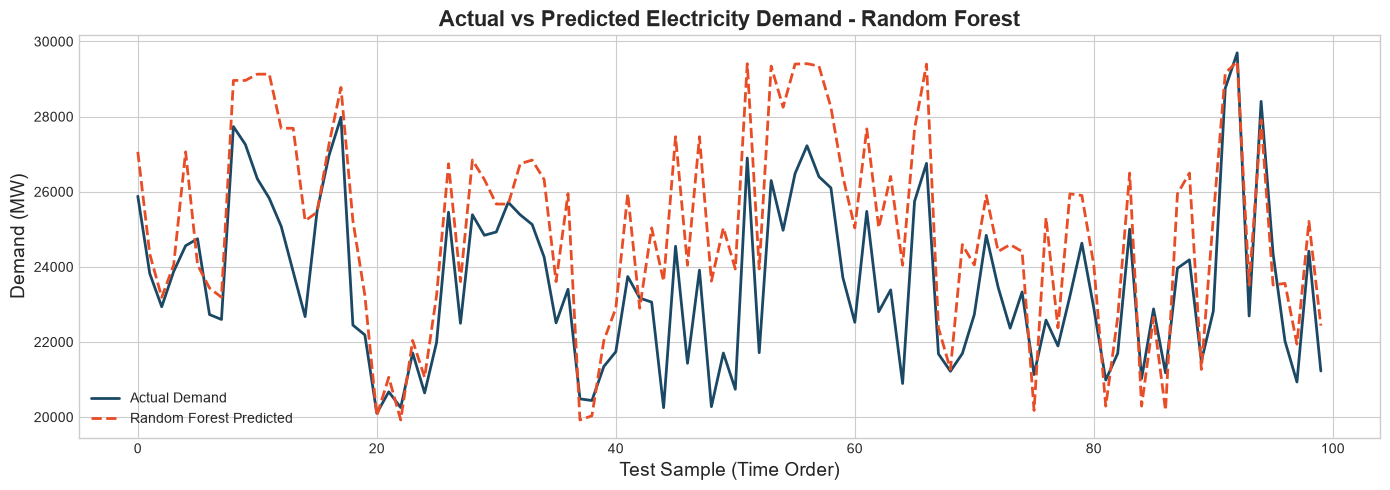

In [64]:
mt.style.use('seaborn-v0_8-whitegrid')
mt.figure(figsize=(14, 5))
mt.plot(Y_test.values[:100], label='Actual Demand', color='#1B4965', linewidth=2)
mt.plot(Y_pred_rf[:100], label='Random Forest Predicted', color="#E84D26", linewidth=2, linestyle='--')
mt.xlabel('Test Sample (Time Order)', fontsize=14)
mt.ylabel('Demand (MW)', fontsize=14)
mt.title('Actual vs Predicted Electricity Demand - Random Forest', fontweight='bold', fontsize=16)
mt.legend()
mt.tight_layout()
mt.savefig('../outputs/actual_vs_predicted_rf.png', dpi=300)
mt.show()

In [51]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE (MW)': [mae, mae_rf, mae_xgb],
    'RMSE (MW)': [rmse, rmse_rf, rmse_xgb],
    'R2 Score': [r2, r2_rf, r2_xgb]})
comparison_df = comparison_df.sort_values('R2 Score', ascending=False).reset_index(drop=True)
comparison_df

,Model,MAE (MW),RMSE (MW),R2 Score
0,Random Forest,2083.777576,2649.211626,0.521658
1,XGBoost,2115.217529,2660.984780,0.517397
2,Linear Regression,4272.446480,5172.362738,-0.823405


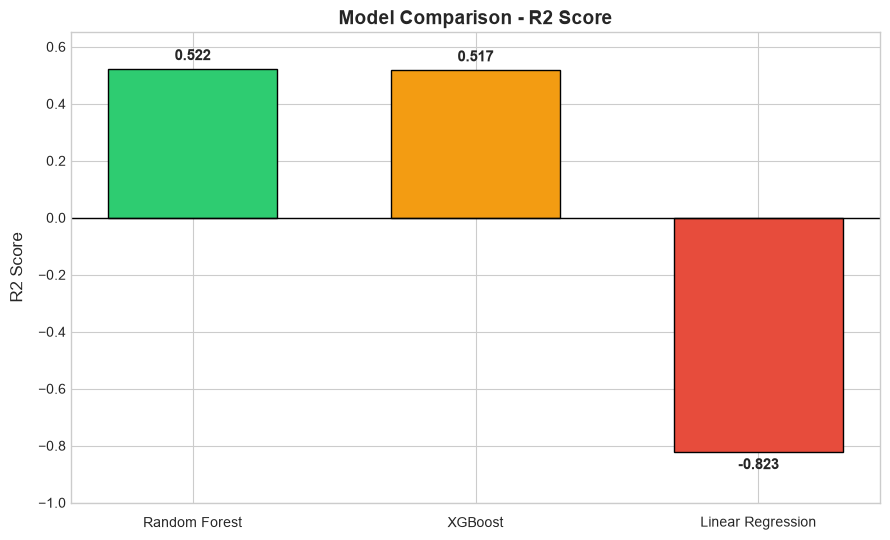

In [77]:
mt.figure(figsize=(9, 5.5))
colors = ['#2ECC71', '#F39C12', '#E74C3C']
bars = mt.bar(comparison_df['Model'], comparison_df['R2 Score'], color=colors, edgecolor='black', linewidth=1, width=0.6)

for bar, score in zip(bars, comparison_df['R2 Score']):
    height = bar.get_height()
    va = 'bottom' if height >= 0 else 'top'
    offset = 0.02 if height >= 0 else -0.02
    mt.text(bar.get_x() + bar.get_width()/2, height + offset, f'{score:.3f}', ha='center', va=va, fontsize=11, fontweight='bold')

mt.ylabel('R2 Score', fontsize=12, labelpad = 9)
mt.title('Model Comparison - R2 Score', fontsize=14, fontweight='bold')
mt.axhline(0, color='black', linewidth=1)
mt.tick_params(axis='x', pad=10)
mt.ylim(-1, 0.65)
mt.tight_layout()

mt.savefig('../outputs/model_comparison_r2.png', dpi=300)
mt.show()

## Conclusions

Three models were trained to forecast UK electricity demand using time-based features (hour, day of week, month, weekend flag):

| Model | MAE (MW) | RMSE (MW) | R² Score |
|---|---|---|---|
| Random Forest | 2,083.78 | 2,649.21 | 0.5217 |
| XGBoost | 2,115.22 | 2,660.98 | 0.5174 |
| Linear Regression | 4,272.45 | 5,172.36 | -0.8234 |

**Random Forest performed best**, explaining ~52% of the variance in electricity demand. Linear Regression performed worse than a naive average-based baseline (negative R²), because it can only model straight-line relationships and cannot capture the cyclical, peak-and-dip nature of daily demand patterns.

XGBoost performed close to, but slightly behind, Random Forest with default hyperparameters — likely due to the relatively small feature set and dataset size limiting the advantage of its iterative error-correction approach. Manual tuning (increased n_estimators, reduced learning_rate, added max_depth) was explored as a next step to potentially close this gap.

**Next steps to improve accuracy further:** additional features such as temperature/weather data, holiday flags, and lagged demand values (e.g., demand 1 hour ago, demand 24 hours ago) would likely improve all three models significantly, since electricity demand is strongly influenced by recent trends, not just calendar features alone.